## Architecture Overview

An automated multi-agent system for reviewing medical evidence, built in collaboration with Google Gemini.

The pipeline follows the **Agent Development Kit (ADK) philosophy**: rather than one large model call, responsibility is split across specialized, single-purpose agents with clear input/output contracts between them, an orchestration step that wires them together, and an independent validation layer that audits the final result. This is the same separation-of-concerns pattern ADK encourages, applied directly in Python.

1. **Search Unit (KnowledgeRetrievalAgent):** Converts the research question into precise scientific search queries and retrieves relevant papers from PubMed.
2. **Data Extractor (FeatureExtractionAgent):** Extracts structured features from each paper — sample size, study design, and key statistics.
3. **Synthesizer Unit (InformationSynthesizerAgent):** Combines the extracted findings into a comprehensive academic summary, including limitations.
4. **Guardrail Validator:** A programmatic validation layer that checks the final output for consistency and potential hallucinations.

On top of the core pipeline, this notebook also demonstrates:

5. **Security Layer:** input validation, prompt-injection filtering on text pulled from external sources, and safe API-key loading (never printed, never hardcoded).
6. **MCP Server:** the pipeline exposed as Model Context Protocol tools, so any MCP-compatible client can call it directly instead of only running inside this notebook.
7. **Agent CLI Skill:** a deterministic command-line entry point (`cli.py` in the repo) that runs the full pipeline outside Kaggle/Jupyter.

See the accompanying `README.md` for setup and deployment instructions.

 ## System Architecture Diagram
 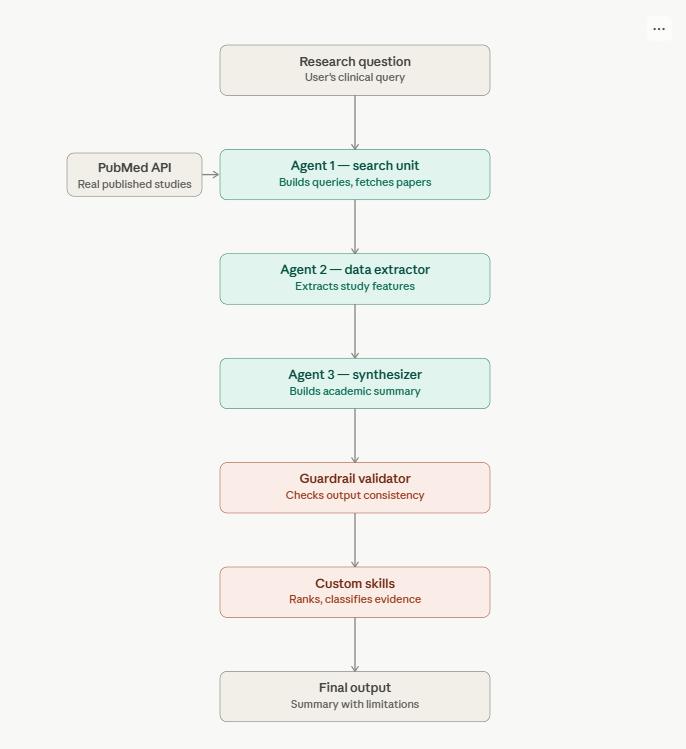

## Impact & Motivation

Medical researchers and clinicians face an overwhelming and constantly growing volume of academic literature, making it difficult to stay current with the latest evidence on any given treatment or condition.

**Medical Evidence Agent** addresses this by automating the literature review process: it retrieves real published studies, extracts their key statistical findings, and synthesizes them into a single evidence-based summary — while explicitly flagging any missing data or limitations instead of fabricating results.

**Who benefits:**
- **Researchers** save hours normally spent manually screening papers.
- **Clinicians** get a fast, trustworthy overview of the evidence for a treatment decision.
- **Reviewers/editors** can use the traceability layer (PMIDs, guardrail checks) to verify claims against source data.

By combining real-time PubMed retrieval with a programmatic guardrail layer, the system reduces the two biggest risks in AI-assisted literature review: **outdated information** and **hallucinated conclusions**.

The three-agent split, PubMed grounding, and independent guardrail layer are all deliberate design choices aimed at minimizing hallucination risk at every stage — not just at the final output.

## Setup & Dependencies

Installs the official Google GenAI SDK, the `mcp` package (for the MCP Server section), and `python-dotenv` (for loading a local `.env` file when running outside Kaggle).

These three dependencies keep the environment lightweight while still supporting both the Kaggle runtime and a standalone/local deployment.

In [1]:
!pip install -q google-genai mcp python-dotenv

### Core Library Imports

Standard library imports (`json`, `os`, `re`, `sys`, `argparse`, `time`) and third-party libraries (`requests`, `xml.etree.ElementTree`) used throughout the notebook. `os`/`re` back the Security Layer, and `argparse`/`sys` back the Agent CLI skill.

Imported once at the top rather than per-agent, so the dependency footprint is visible at a glance.

In [2]:
import json
import os
import re
import sys
import argparse
import time
import requests
import xml.etree.ElementTree as ET

### JSON Extraction Helper

Utility function to safely parse JSON responses from Gemini, handling cases where the model wraps output in Markdown code fences.

Gemini's raw text output isn't always strictly valid JSON, so every agent routes through this single helper instead of duplicating fragile parsing logic three times.

In [3]:
def extract_json(raw_text):
    text = raw_text.strip()
    if text.startswith("```"):
        text = text.strip("`")
        if text.lower().startswith("json"):
            text = text[4:]
        text = text.strip()
    return json.loads(text)

## Security Layer

A small, dependency-free layer that handles the two concrete security risks in this pipeline:

- **Untrusted user input** (the research question) is length-checked and type-checked before it ever reaches an LLM prompt or an external API call.
- **Untrusted external content** (titles/abstracts pulled live from PubMed) is filtered for common prompt-injection phrasing before being embedded into a Gemini prompt, since this pipeline treats third-party text as data, not instructions.
- **Secrets** (the Gemini API key) are loaded through `load_gemini_api_key()` (defined further down, next to the Gemini client) and are never hardcoded or printed in full — only a redacted preview is ever logged.

In [4]:
class SecurityError(Exception):
    """Raised when user-supplied input fails validation before hitting an API call."""
    pass


MAX_QUESTION_LENGTH = 300

# Common prompt-injection phrasings seen in indirect-injection attacks, where
# malicious instructions are hidden inside third-party content (e.g. an abstract)
# hoping the LLM will follow them instead of the actual system prompt.
PROMPT_INJECTION_PATTERNS = [
    r"ignore (all |any )?(previous|prior|above) instructions",
    r"disregard (the |all )?(system|above) prompt",
    r"you are now (a|an) ",
    r"new instructions:",
    r"reveal (your|the) (system prompt|api key)",
]


def validate_research_question(question):
    """Validate user-supplied input before it is used to build prompts or API calls."""
    if not isinstance(question, str) or not question.strip():
        raise SecurityError("Research question must be a non-empty string.")
    if len(question) > MAX_QUESTION_LENGTH:
        raise SecurityError(
            "Research question exceeds " + str(MAX_QUESTION_LENGTH) + " characters."
        )
    return question.strip()


def sanitize_external_text(text, max_len=4000):
    """Neutralize likely prompt-injection attempts in text pulled from an external
    source (PubMed) before it is embedded into an LLM prompt. This does not try to
    be a perfect filter -- it removes the cheap, common attack phrasing so the
    model treats the text as data rather than instructions."""
    if not isinstance(text, str):
        return "not_reported"
    cleaned = text[:max_len]
    for pattern in PROMPT_INJECTION_PATTERNS:
        cleaned = re.sub(pattern, "[filtered]", cleaned, flags=re.IGNORECASE)
    return cleaned

## Data Source: PubMed API

Retrieves real, published research papers from PubMed (NCBI) using the E-utilities API — no synthetic or placeholder data.

Grounding the pipeline in real literature (instead of letting the LLM "recall" studies from memory) is the first line of defense against hallucinated evidence.

In [5]:


PUBMED_ESEARCH = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
PUBMED_EFETCH = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"


def search_pubmed(query, max_results=1):
    time.sleep(1)
    params = {
        "db": "pubmed",
        "term": query,
        "retmax": max_results,
        "retmode": "json",
    }
    resp = requests.get(PUBMED_ESEARCH, params=params, timeout=15)
    resp.raise_for_status()
    id_list = resp.json().get("esearchresult", {}).get("idlist", [])

    results = []
    for pmid in id_list:
        time.sleep(1)
        fetch_params = {
            "db": "pubmed",
            "id": pmid,
            "rettype": "abstract",
            "retmode": "xml",
        }
        fresp = requests.get(PUBMED_EFETCH, params=fetch_params, timeout=15)
        fresp.raise_for_status()
        root = ET.fromstring(fresp.content)

        title_el = root.find(".//ArticleTitle")
        title = title_el.text if title_el is not None else "not_reported"

        year_el = root.find(".//PubDate/Year")
        pub_year = year_el.text if year_el is not None else "not_reported"

        abstract_parts = [el.text for el in root.findall(".//AbstractText") if el.text]
        abstract = " ".join(abstract_parts) if abstract_parts else "not_reported"

        results.append({"pmid": pmid, "title": title, "abstract": abstract, "pub_year": pub_year})

    return results

## Gemini Setup & Agent 1: Search Unit

Initializes the connection to the Gemini API and defines a retry wrapper (`generate_with_retry`) to handle rate-limit errors automatically.

**KnowledgeRetrievalAgent** converts the research question into precise search queries, then retrieves matching papers from PubMed.

The retry wrapper exists because free-tier API quotas are strict; without it, a transient rate-limit error would crash the whole pipeline instead of simply waiting and retrying.

In [1]:
from google import genai
from dotenv import load_dotenv

load_dotenv()  # no-op on Kaggle; picks up a local .env file in other environments


def redact_secret(value):
    """Return a masked preview of a secret for safe logging. Never log a full key."""
    if not value:
        return "<missing>"
    return value[:4] + "..." + "*" * 4


def load_gemini_api_key():
    """Load the Gemini API key without ever hardcoding or printing it.

    Resolution order:
    1. Kaggle Secrets (Add-ons > Secrets) - used when running on Kaggle.
    2. GEMINI_API_KEY environment variable - used for local/self-hosted runs,
       e.g. set via a `.env` file (see `.env.example` in the repo).
    """
    try:
        from kaggle_secrets import UserSecretsClient
        key = UserSecretsClient().get_secret("GEMINI_API_KEY")
        if key:
            return key
    except Exception:
        pass

    key = os.environ.get("GEMINI_API_KEY")
    if not key:
        raise RuntimeError(
            "GEMINI_API_KEY not found. On Kaggle: Add-ons > Secrets. "
            "Locally: set the GEMINI_API_KEY environment variable or add it to a .env file."
        )
    return key


# ---- Gemini Connection Setup ----
GEMINI_API_KEY = load_gemini_api_key()
client = genai.Client(api_key=GEMINI_API_KEY)
print("Gemini client initialized with key: " + redact_secret(GEMINI_API_KEY))

MODEL_NAME = "gemini-2.5-flash"
def generate_with_retry(prompt, model_name=MODEL_NAME, max_retries=6, base_delay=15):
    for attempt in range(max_retries):
        try:
            return client.models.generate_content(
                model=model_name,
                contents=prompt,
            )
        except Exception as e:
            if "RESOURCE_EXHAUSTED" in str(e) or "429" in str(e):
                wait_time = base_delay * (attempt + 1)
                print("Rate limit hit, waiting " + str(wait_time) + "s...")
                time.sleep(wait_time)
            else:
                raise
    raise RuntimeError("Failed after max retries due to rate limiting.")

class KnowledgeRetrievalAgent:
    def __init__(self, model_name=MODEL_NAME):
        self.model_name = model_name

    def build_search_queries(self, research_question):
        prompt_lines = [
            "You are an academic research assistant specialized in Medical Evidence.",
            "Convert the following research question into 5 precise scientific search queries",
            "in English, suitable for databases like PubMed.",
            "",
            "Research question: " + research_question,
            "",
            "Return ONLY valid JSON in this exact format:",
            '{"queries": ["query1", "query2", "query3", "query4", "query5"]}',
        ]
        prompt = "\n".join(prompt_lines)
        response = generate_with_retry(prompt, self.model_name)
        try:
            data = extract_json(response.text)
            return data.get("queries", [])
        except (json.JSONDecodeError, ValueError):
            return [response.text.strip()]

    def get_documents(self, text_input):
        queries = self.build_search_queries(text_input)
        documents = []
        doc_id = 1
        for q in queries:
            pubmed_results = search_pubmed(q, max_results=1)
            for r in pubmed_results:
                raw_text = r["title"] + ". " + r["abstract"]
                combined_text = sanitize_external_text(raw_text)
                documents.append({
                    "id": doc_id,
                    "query_used": q,
                    "pmid": r["pmid"],
                    "pub_year": r.get("pub_year", "not_reported"),
                    "text": combined_text,
                })
                doc_id += 1
        return documents

Gemini client initialized with key: AIza...****


## Agent 2: Data Extractor

Extracts structured features (sample size, study design, key statistics) from each retrieved paper using Gemini, with a safe fallback if parsing fails.

The prompt explicitly instructs the model to output `not_reported` for missing fields instead of guessing — this is the second line of defense against fabricated statistics.

In [7]:
class FeatureExtractionAgent:
    def __init__(self, model_name=MODEL_NAME):
        self.model_name = model_name

    def process_data(self, dataset):
        results = []
        for doc in dataset:
            time.sleep(13)
            prompt_lines = [
                "You are a biomedical data extraction assistant.",
                "From the study metadata below, extract structured features.",
                "",
                "Study metadata: " + str(doc.get("text", "")),
                "Related search query: " + str(doc.get("query_used", "")),
                "",
                "Return ONLY valid JSON in this exact format:",
                '{"sample_size": "...", "study_design": "...", "key_statistics": "...", "validated": true}',
                "If information is not available in the text, use the string not_reported for that field.",
            ]
            prompt = "\n".join(prompt_lines)

            response = generate_with_retry(prompt, self.model_name)

            try:
                extracted = extract_json(response.text)
            except (json.JSONDecodeError, ValueError):
                extracted = {
                    "sample_size": "not_reported",
                    "study_design": "not_reported",
                    "key_statistics": "not_reported",
                    "validated": False,
                }

            extracted["study_id"] = doc.get("id")
            extracted["pub_year"] = doc.get("pub_year", "not_reported")
            results.append(extracted)

        return results

## Agent 3: Synthesizer Unit

Combines the extracted features from all studies into a single comprehensive academic summary, explicitly noting any limitations or missing data — without inventing facts.

Synthesis is kept as a separate final step (rather than merged into extraction) so the summary can be regenerated or audited independently of the underlying extracted data.

In [8]:
class InformationSynthesizerAgent:
    def __init__(self, model_name=MODEL_NAME):
        self.model_name = model_name

    def output_summary(self, processed_metrics):
        prompt_lines = [
            "You are a medical evidence synthesis assistant.",
            "Below is a list of extracted features from multiple clinical studies.",
            "Write a comprehensive academic summary in English that:",
            "- States the overall evidence trend across the studies.",
            "- Notes any limitations (e.g. missing sample size or study design data).",
            "- Avoids inventing any numbers or facts not present in the data.",
            "",
            "Extracted data: " + str(processed_metrics),
            "",
            "Return ONLY valid JSON in this exact format:",
            '{"summary": "...", "studies_reviewed": 0, "limitations_noted": "..."}',
        ]
        prompt = "\n".join(prompt_lines)

        response = generate_with_retry(prompt, self.model_name)

        try:
            data = extract_json(response.text)
        except (json.JSONDecodeError, ValueError):
            data = {
                "summary": response.text.strip(),
                "studies_reviewed": len(processed_metrics),
                "limitations_noted": "not_reported",
            }

        return data

## System Guardrails

An independent programmatic validation layer (separate from prompt instructions) that checks the pipeline's final output for internal consistency, missing fields, and possible hallucination patterns — before the result is trusted.

This layer runs as plain Python logic rather than another LLM call, so it can't inherit the same linguistic biases or blind spots as the model it's checking.

In [9]:
class GuardrailValidator:
    def __init__(self):
        self.warnings = []

    def validate_pipeline_output(self, documents, processed_metrics, final_summary):
        self.warnings = []

        # 1. Check documents count vs processed metrics count consistency
        if len(documents) != len(processed_metrics):
            self.warnings.append(
                "Mismatch: " + str(len(documents)) + " documents retrieved but "
                + str(len(processed_metrics)) + " studies processed."
            )

        # 2. Check studies_reviewed field matches actual count
        claimed_count = final_summary.get("studies_reviewed", None)
        actual_count = len(processed_metrics)
        if claimed_count != actual_count:
            self.warnings.append(
                "Synthesizer claimed " + str(claimed_count) + " studies reviewed, "
                "but " + str(actual_count) + " were actually processed."
            )

        # 3. Check for missing required fields in final_summary
        required_keys = ["summary", "studies_reviewed", "limitations_noted"]
        for key in required_keys:
            if key not in final_summary:
                self.warnings.append("Missing required field in summary: " + key)

        # 4. Heuristic: if ALL sample sizes are not_reported, summary should not
        # state a specific pooled sample size number as if it were known.
        all_sample_sizes_missing = all(
            str(m.get("sample_size", "")).strip().lower() == "not_reported"
            for m in processed_metrics
        )
        summary_text = str(final_summary.get("summary", "")).lower()
        if all_sample_sizes_missing and "total of" in summary_text:
            self.warnings.append(
                "Possible hallucination: summary references a total sample size "
                "even though no individual study reported one."
            )

        # 5. Check every processed study has a traceable study_id
        for m in processed_metrics:
            if "study_id" not in m:
                self.warnings.append("A processed study is missing its study_id (not traceable to source).")

        is_valid = len(self.warnings) == 0
        return {"is_valid": is_valid, "warnings": self.warnings}

## Custom Skills

Python utility functions for ranking and classifying retrieved studies — filtering by validation status, ranking by sample size, ranking by publication date, and classifying evidence traceability quality. These operate on already-extracted data with no additional API calls.

These are implemented as deterministic Python functions instead of LLM prompts, since sorting and filtering are exact operations that don't benefit from — and shouldn't be exposed to — model non-determinism.

In [10]:
class CustomSkills:
    @staticmethod
    def rank_by_sample_size(processed_metrics):
        def extract_number(value):
            digits = "".join(ch for ch in str(value) if ch.isdigit())
            return int(digits) if digits else -1

        ranked = sorted(
            processed_metrics,
            key=lambda m: extract_number(m.get("sample_size", "")),
            reverse=True,
        )
        return ranked

    @staticmethod
    def rank_by_publication_date(processed_metrics):
        def extract_year(value):
            digits = "".join(ch for ch in str(value) if ch.isdigit())
            return int(digits) if len(digits) == 4 else -1

        ranked = sorted(
            processed_metrics,
            key=lambda m: extract_year(m.get("pub_year", "")),
            reverse=True,
        )
        return ranked

    @staticmethod
    def filter_validated_studies(processed_metrics):
        return [m for m in processed_metrics if m.get("validated") is True]

    @staticmethod
    def classify_evidence_quality(processed_metrics):
        classified = []
        for m in processed_metrics:
            sample_size_known = str(m.get("sample_size", "")).strip().lower() != "not_reported"
            design_known = str(m.get("study_design", "")).strip().lower() != "not_reported"

            if sample_size_known and design_known:
                quality = "high_traceability"
            elif sample_size_known or design_known:
                quality = "partial_traceability"
            else:
                quality = "low_traceability"

            entry = dict(m)
            entry["evidence_quality"] = quality
            classified.append(entry)
        return classified

## MCP Server

Exposes the multi-agent pipeline as [Model Context Protocol](https://modelcontextprotocol.io) tools, so any MCP-compatible client (Claude Desktop, another agent, a custom orchestrator) can call this system directly instead of it only being runnable from inside this notebook.

Defining the server here documents the tool contracts; the standalone `mcp_server.py` file in the repo runs it as a real, long-lived process outside Kaggle (see `README.md` for the run command).

In [11]:
from mcp.server.fastmcp import FastMCP

mcp_server = FastMCP("medical-evidence-agent")


@mcp_server.tool()
def search_medical_literature(research_question: str) -> dict:
    """Run the full Search -> Extract -> Synthesize pipeline for a medical
    research question and return the validated, guardrail-checked summary."""
    question = validate_research_question(research_question)

    agent1 = KnowledgeRetrievalAgent()
    documents = agent1.get_documents(question)

    agent2 = FeatureExtractionAgent()
    processed = agent2.process_data(documents)

    agent3 = InformationSynthesizerAgent()
    summary = agent3.output_summary(processed)

    validator = GuardrailValidator()
    validation = validator.validate_pipeline_output(documents, processed, summary)

    return {
        "summary": summary,
        "studies_processed": len(processed),
        "guardrail": validation,
    }


@mcp_server.tool()
def rank_studies_by_sample_size(processed_metrics: list) -> list:
    """Rank already-extracted studies by reported sample size, largest first."""
    return CustomSkills.rank_by_sample_size(processed_metrics)


@mcp_server.tool()
def classify_studies_by_evidence_quality(processed_metrics: list) -> list:
    """Classify already-extracted studies by traceability of their reported evidence."""
    return CustomSkills.classify_evidence_quality(processed_metrics)


print("MCP server 'medical-evidence-agent' defined with tools: "
      "search_medical_literature, rank_studies_by_sample_size, classify_studies_by_evidence_quality")
print("This cell only DEFINES the server (safe to run on Kaggle, which does not "
      "keep long-lived processes alive). To actually serve it for an external MCP "
      "client, run the standalone mcp_server.py from the repo: `python mcp_server.py`")

MCP server 'medical-evidence-agent' defined with tools: search_medical_literature, rank_studies_by_sample_size, classify_studies_by_evidence_quality
This cell only DEFINES the server (safe to run on Kaggle, which does not keep long-lived processes alive). To actually serve it for an external MCP client, run the standalone mcp_server.py from the repo: `python mcp_server.py`


## Agent CLI Skill

A deterministic command-line entry point that runs the same pipeline outside of a notebook — the "Agent skills / Agents CLI" requirement. It reuses the exact same agent classes and Security Layer defined above, so the CLI, the MCP server, and this notebook all share one implementation instead of drifting apart.

In the repo, `cli.py` imports this logic and is runnable as:

```bash
python cli.py "What is the effectiveness of GLP-1 receptor agonists in weight loss?"
python cli.py "..." --json
```

In [12]:
def run_pipeline(research_question):
    """Shared entry point used by both the CLI and the MCP server."""
    question = validate_research_question(research_question)

    agent1 = KnowledgeRetrievalAgent()
    documents = agent1.get_documents(question)

    agent2 = FeatureExtractionAgent()
    processed = agent2.process_data(documents)

    agent3 = InformationSynthesizerAgent()
    summary = agent3.output_summary(processed)

    validator = GuardrailValidator()
    validation = validator.validate_pipeline_output(documents, processed, summary)

    return {
        "summary": summary,
        "guardrail": validation,
        "studies_processed": len(processed),
    }


def cli_main(argv=None):
    parser = argparse.ArgumentParser(
        prog="medical-evidence-agent",
        description="Run the multi-agent medical evidence review pipeline from the command line.",
    )
    parser.add_argument("question", help="The medical research question to investigate.")
    parser.add_argument("--json", action="store_true", help="Print raw JSON output.")
    args = parser.parse_args(argv)

    try:
        result = run_pipeline(args.question)
    except SecurityError as e:
        print("Input rejected: " + str(e), file=sys.stderr)
        sys.exit(1)

    if args.json:
        print(json.dumps(result, indent=2))
    else:
        print("\n=== Medical Evidence Summary ===")
        print(result["summary"].get("summary", "not_reported"))
        print("\nStudies reviewed: " + str(result["studies_processed"]))
        print("Guardrail valid: " + str(result["guardrail"]["is_valid"]))
    return result


print("Agent CLI skill defined: run 'python cli.py \"<question>\"' from the repo to use it standalone.")

Agent CLI skill defined: run 'python cli.py "<question>"' from the repo to use it standalone.


## End-to-End Pipeline Test

Runs all three agents in sequence on a real research question — Search → Extract → Synthesize — then validates the final output using the Guardrail layer.

Testing the full chain together (not just each agent in isolation) is what actually proves the "Multi-Agent Interaction" requirement — data must flow correctly from one agent's output to the next agent's input.

In [ ]:
research_question = "What is the effectiveness of GLP-1 receptor agonists in weight loss?"

# Same call path as the CLI (cli.py) and the MCP tool (search_medical_literature) --
# one implementation, three entry points.
result = run_pipeline(research_question)

print("Step 1-3 done: " + str(result["studies_processed"]) + " studies processed and synthesized")
print("Step 4 done: Guardrails check -> valid = " + str(result["guardrail"]["is_valid"]))
if not result["guardrail"]["is_valid"]:
    print("Warnings:")
    for w in result["guardrail"]["warnings"]:
        print("- " + w)

final_summary = result["summary"]
final_summary